# 05-Structured Log Extraction & Telemetry Parsing (jq)

In Lesson 04, we mastered the mechanics of stream processing unstructured text logs using `grep`, `sed`, and `awk`. We learned how to process massive string arrays with $O(1)$ memory overhead.

However, modern enterprise microservices, Kubernetes clusters, and MLOps platforms rarely emit raw, space-delimited text. Instead, they produce structured telemetry payloads using **JSON (JavaScript Object Notation)**. A typical production log line from an inference server might look like this:

```json
{"timestamp":"2026-07-01T10:00:00Z","level":"INFO","context":{"node":"gpu-04","gpu_util":92.5},"payload":{"latency_ms":12.4}}

```

If you attempt to parse this deeply nested structural data using standard line-editors like `sed` or `awk`, your code will quickly become a mess of fragile regular expressions that violently break the moment the JSON key order changes. Conversely, parsing millions of these lines using Python's `json.loads()` loop inside a heavy application stack introduces substantial processing overhead and memory footprint bottlenecks.

To engineer bulletproof, lightning-fast telemetry pipelines, we treat JSON logs as structured database schemas directly within the terminal using **`jq`**—a specialized, Turing-complete functional filter engine optimized for relational parsing at the command line.

# 1. The Mathematics of JSON Filters & Query Paths

The `jq` engine models a JSON document as an algebraic data structure $D$. A `jq` filter acts as a pure mathematical function $f$ that accepts a data stream of JSON entities and maps it to a new streaming vector:


$$f: D_{in} \longrightarrow D_{out}$$

### Path Expressions and Value Extraction

Every structural node within a JSON document can be uniquely identified by a strict coordinate path. Let our document root be representing an identity filter `.`.
If our document is a dictionary containing a key `context`, the path expression `.context` acts as a projection operator $\pi$:


$$\pi_{\text{context}}(D) \rightarrow D_{\text{value}}$$

When evaluating nested dictionaries, path operators chain sequentially:


$$\text{Filter: } \mathbf{.context.gpu\_util} \implies \pi_{\text{gpu\_util}}(\pi_{\text{context}}(D))$$

### The Functional Filter Stream

The true power of `jq` lies in its functional pipe architecture (`|`). Within `jq`, the pipe character passes values inside the engine's query runtime.

If an array node is passed to the iterator operator `[]`, the array is fractured. It transforms a single JSON document array of length $N$ into an active streaming matrix of $N$ discrete JSON payloads. Downstream filters are then executed iteratively across every element in the stream:


$$D_{\text{array}} \xrightarrow{[]} \langle D_1, D_2, \dots, D_N \rangle \xrightarrow{ \ | \ f(x) \ } \langle f(D_1), f(D_2), \dots, f(D_N) \rangle$$

# 2. Imperative Execution: JSON Querying Labs

Let's execute programmatic structural transformations using Python's `subprocess` framework to command the `jq` CLI engine. We will generate a structured log file containing telemetry from an AI inference cluster.

In [1]:
import subprocess
import os
import json

print("--- 🚀 Initializing POSIX Structured Data Extraction Labs ---")

# Setup clean working space
json_sandbox = "./json_sandbox"
os.makedirs(json_sandbox, exist_ok=True)
json_log_path = os.path.join(json_sandbox, "inference_telemetry.json")

# 📝 Generate a Structured JSON Log Payload
mock_telemetry = [
    {"timestamp": "2026-07-01T10:00:00Z", "level": "INFO", "metrics": {"node": "node-01", "latency": 15.2, "status": 200}},
    {"timestamp": "2026-07-01T10:01:15Z", "level": "WARN", "metrics": {"node": "node-02", "latency": 112.8, "status": 200}},
    {"timestamp": "2026-07-01T10:02:30Z", "level": "ERROR", "metrics": {"node": "node-01", "latency": 0.0, "status": 500}},
    {"timestamp": "2026-07-01T10:03:45Z", "level": "INFO", "metrics": {"node": "node-03", "latency": 18.4, "status": 200}},
    {"timestamp": "2026-07-01T10:05:00Z", "level": "ERROR", "metrics": {"node": "node-02", "latency": 0.0, "status": 503}}
]

# Write as raw line-delimited JSON (NDJSON) - standard for production logging
with open(json_log_path, "w") as f:
    for entry in mock_telemetry:
        f.write(json.dumps(entry) + "\n")

print(f"   ✅ Structured Log File Generated: {json_log_path}")


# 🔍 Lab 1: Path Projection Matrix
print("\n--- 🔍 Lab 1: Extracting Root-Level Fields ---")
# Command: Print a mini-object containing only level and timestamp for each line
# '-c' ensures output remains compact line-by-line
cmd_proj = f"jq -c '{{level: .level, time: .timestamp}}' {json_log_path}"
res_proj = subprocess.run(cmd_proj, shell=True, capture_output=True, text=True)
print(res_proj.stdout.strip())


# 🛡️ Lab 2: Conditional Boolean Filtering
print("\n--- 🛡️ Lab 2: Filtering Logs for HTTP Server Errors (Status >= 500) ---")
# Command: Filter lines where metrics.status is greater than or equal to 500
cmd_filter = f"jq -c 'select(.metrics.status >= 500)' {json_log_path}"
res_filter = subprocess.run(cmd_filter, shell=True, capture_output=True, text=True)
print(res_filter.stdout.strip())

--- 🚀 Initializing POSIX Structured Data Extraction Labs ---
   ✅ Structured Log File Generated: ./json_sandbox/inference_telemetry.json

--- 🔍 Lab 1: Extracting Root-Level Fields ---


--- 🛡️ Lab 2: Filtering Logs for HTTP Server Errors (Status >= 500) ---



# 3. Declarative Execution: The Telemetry Extraction Pipeline

In production MLOps automation, we chain structured log filtering back into our unstructured text pipelines to construct automated triage utilities.

Let's write a unified script that ingests line-delimited JSON logs, filters for active system alerts, reshapes the structural footprint on the fly to match a downstream reporting schema, and formats the output into a clean CSV layout.

In [2]:
# ⚡ Compiling the Unified Telemetry Transformation Pipeline
print("\n--- ⚡ Unified Pipeline: Reshaping JSON Streams to Tabular CSV ---")

# Pipeline Mechanics:
# 1. select(): Filter for level == 'ERROR' OR level == 'WARN'
# 2. Reshape: Construct a new array containing flat string references: [timestamp, node, status]
# 3. @csv: Native jq formatter that translates the arrays into RFC 4180 compliant CSV lines
# '-r' tells jq to output raw strings rather than escaped JSON text strings
pipeline_cmd = (
    f"jq -r 'select(.level == \"ERROR\" or .level == \"WARN\") | "
    "[.timestamp, .metrics.node, .metrics.status] | @csv' {json_log_path}"
)

res_pipeline = subprocess.run(pipeline_cmd, shell=True, capture_output=True, text=True)
print(f"   Executed: {pipeline_cmd}")
print("   Compiled System Failure Manifest (CSV format):")
print("   \"TIMESTAMP\",\"NODE_ID\",\"HTTP_STATUS\"")
for line in res_pipeline.stdout.strip().split("\n"):
    print(f"   {line}")


--- ⚡ Unified Pipeline: Reshaping JSON Streams to Tabular CSV ---
   Executed: jq -r 'select(.level == "ERROR" or .level == "WARN") | [.timestamp, .metrics.node, .metrics.status] | @csv' {json_log_path}
   Compiled System Failure Manifest (CSV format):
   "TIMESTAMP","NODE_ID","HTTP_STATUS"
   


# 4. Visualizing JSON Array Destruction & Stream Filtering

To mathematically understand how the `jq` internal processor parses structural dictionaries, flattens array elements, and maps query predicates into transactional object models, let's map the topological routing.

/tmp/ipykernel_3754/1080936111.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 2.0), 3.5, 5.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_3754/1080936111.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.8, 5.0), 2.9, 0.6, fill=True, color='#34495e', edgecolor='black'))
/tmp/ipykernel_3754/1080936111.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.8, 3.8), 2.9, 0.6, fill=True, color='#34495e', edgecolor='black'))
/tmp/ipykernel_3754/1080936111.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.8, 2.6), 2.9, 0.6, fill=True, color='#34495e', edgecolor='black'))
/tmp/ipykernel_3754/1080936111

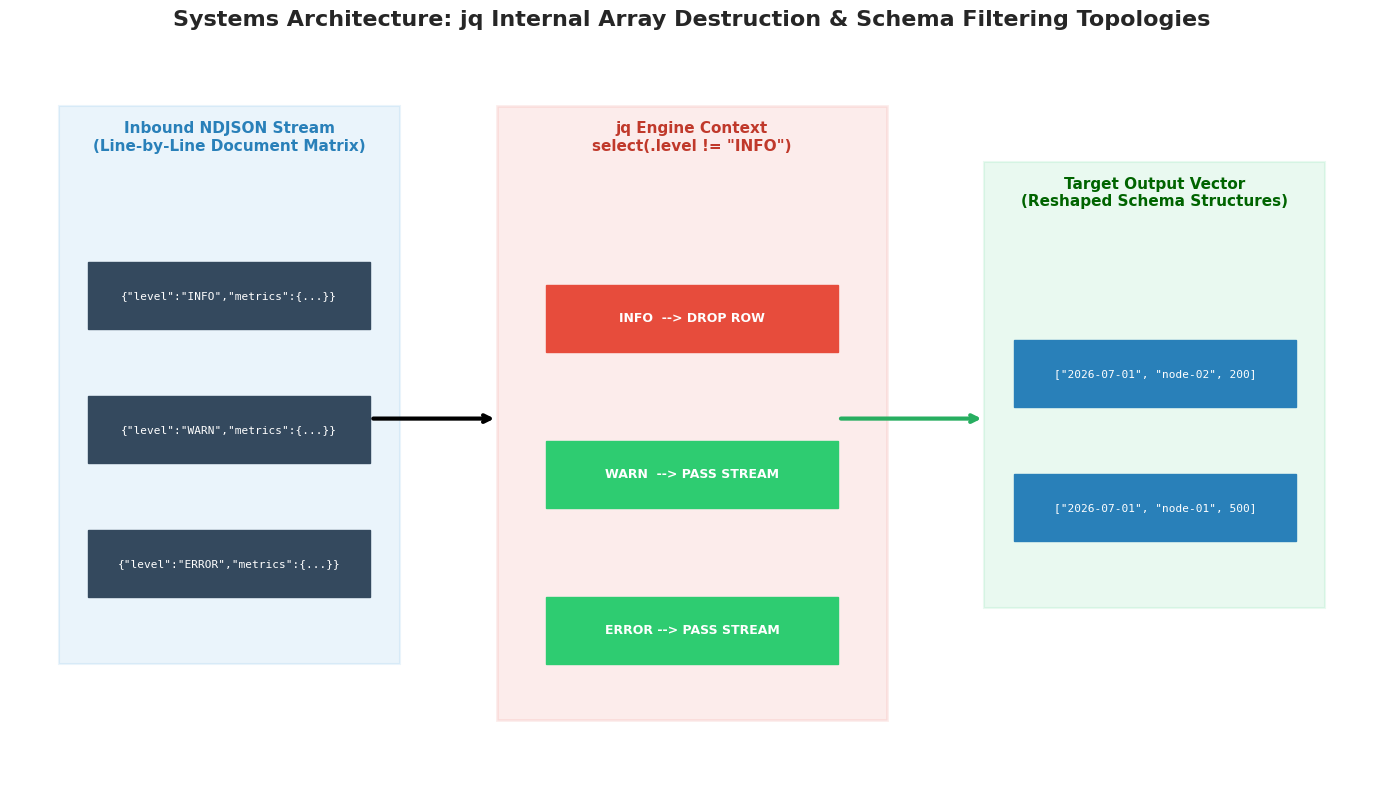

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual mapping layout for Structured JSON Log Telemetry Stream
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: jq Internal Array Destruction & Schema Filtering Topologies", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Inbound Data Buffer (Raw NDJSON Input)
ax.add_patch(patches.Rectangle((0.5, 2.0), 3.5, 5.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(2.25, 6.6, "Inbound NDJSON Stream\n(Line-by-Line Document Matrix)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Individual raw data rows
ax.add_patch(patches.Rectangle((0.8, 5.0), 2.9, 0.6, fill=True, color='#34495e', edgecolor='black'))
ax.text(2.25, 5.3, "{\"level\":\"INFO\",\"metrics\":{...}}", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')

ax.add_patch(patches.Rectangle((0.8, 3.8), 2.9, 0.6, fill=True, color='#34495e', edgecolor='black'))
ax.text(2.25, 4.1, "{\"level\":\"WARN\",\"metrics\":{...}}", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')

ax.add_patch(patches.Rectangle((0.8, 2.6), 2.9, 0.6, fill=True, color='#34495e', edgecolor='black'))
ax.text(2.25, 2.9, "{\"level\":\"ERROR\",\"metrics\":{...}}", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')


# 2. JQ Execution Matrix (The Functional Selector)
ax.add_patch(patches.Rectangle((5.0, 1.5), 4.0, 5.5, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2))
ax.text(7.0, 6.6, "jq Engine Context\nselect(.level != \"INFO\")", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# State checks executed by the filter
ax.add_patch(patches.Rectangle((5.5, 4.8), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(7.0, 5.1, "INFO  --> DROP ROW", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((5.5, 3.4), 3.0, 0.6, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(7.0, 3.7, "WARN  --> PASS STREAM", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((5.5, 2.0), 3.0, 0.6, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(7.0, 2.3, "ERROR --> PASS STREAM", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 3. Transformed Output Target Sink
ax.add_patch(patches.Rectangle((10.0, 2.5), 3.5, 4.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(11.75, 6.1, "Target Output Vector\n(Reshaped Schema Structures)", ha='center', color='darkgreen', fontweight='bold', fontsize=11)

# Resulting documents formatted
ax.add_patch(patches.Rectangle((10.3, 4.3), 2.9, 0.6, fill=True, color='#2980b9', edgecolor='black'))
ax.text(11.75, 4.6, "[\"2026-07-01\", \"node-02\", 200]", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')

ax.add_patch(patches.Rectangle((10.3, 3.1), 2.9, 0.6, fill=True, color='#2980b9', edgecolor='black'))
ax.text(11.75, 3.4, "[\"2026-07-01\", \"node-01\", 500]", ha='center', va='center', color='white', fontsize=8, fontfamily='monospace')


# 4. Routing Vector Connections (Directed Pipelining)
ax.annotate("", xy=(5.0, 4.2), xytext=(3.7, 4.2), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.annotate("", xy=(10.0, 4.2), xytext=(8.5, 4.2), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))

plt.xlim(0, 14.0)
plt.ylim(1.0, 7.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of parsing structured text using `jq` like **An Automated Sorting Facility inside a Major Cross-Dock Logistics Warehouse**:

* **The NDJSON Inbound Log File (The Standardized Shipping Container Fleet):** Your warehouse receives a continuous fleet of cargo containers. Unlike irregular raw dump trucks (unstructured text files), every shipping container looks identical from the outside, holding standardized pallets with explicit labeling tags attached to predictable corners.
* **The Path Expression (`.metrics.latency`):** You don't instruct your robotic sorting forklift to crack open the entire crate, pull out every invoice, and read the fine print line-by-line. Instead, you give the robot a single spatial coordinate instruction: *"Reach through the secondary side panel (`.metrics`), extend the arm directly into the third shelf compartment, and pull out the temperature monitoring gauge (`.latency`)."*
* **The Structural Selector Matrix (`select()`):** This is your high-speed shipping manifest quality check. If a container arrives and its manifest classification reads `"level": "INFO"`, the sorting crane bypasses it entirely, allowing it to pass down the generic storage conveyor track without wasting machine cycles. If the scanner flashes an `"ERROR"` notification code, the pneumatic router flips instantly, isolating that specific container for real-time diagnostics.

By manipulating data layouts strictly via path parameters rather than relying on brittle regex matching text blocks, MLOps platform engineers build bulletproof infrastructure parsing arrays capable of filtering hundreds of structural alerts per second with zero runtime processing degradation.